# DDPM Tasks 3-5

In [5]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch

from src.config import get_device
from src.eval import sample_and_save_grid, save_denoising_trajectory
from src.models.unet import TinyUNet
from src.train import (
    train_ddpm,
    train_ddpm_overfit_subset,
    load_ddpm_checkpoint,
    one_step_posterior_sanity_check,
    noise_prediction_sanity_check,
    timestep_uniformity_sanity_check,
)
from src.utils.io import save_checkpoint
from src.utils.viz import plot_training_diagnostics, plot_timestep_histogram


In [6]:
TASK4_CKPT = Path("outputs/checkpoints/tiny_unet_mnist.pt")
OVERFIT_CKPT = Path("outputs/checkpoints/tiny_unet_mnist_overfit256.pt")
TASK5_CKPT = Path("outputs/checkpoints/tiny_unet_mnist_task5.pt")

## Task 3:

In [7]:
device = get_device()
model_check = TinyUNet().to(device)
x = torch.randn(4, 1, 28, 28, device=device)
t = torch.randint(0, 1000, (4,), device=device)
y = model_check(x, t)
print("Input shape:", tuple(x.shape))
print("Output shape:", tuple(y.shape))

Input shape: (4, 1, 28, 28)
Output shape: (4, 1, 28, 28)


## Task 4:

In [ ]:
RUN_TASK4_TRAIN = True

if RUN_TASK4_TRAIN or (not TASK4_CKPT.exists()):
    model, schedule, losses, train_stats = train_ddpm(
        steps=7000,
        batch_size=128,
        sample_every=3500,
        checkpoint_path=TASK4_CKPT,
        return_stats=True,
    )
    print("Training complete. Last loss:", losses[-1])
    print("Saved checkpoint:", train_stats["checkpoint_path"])
    print("Periodic sample grids:")
    for p in train_stats["sample_paths"]:
        print(" -", p)
else:
    model, schedule = load_ddpm_checkpoint(TASK4_CKPT)
    losses = []
    train_stats = {"losses": [], "grad_norms": [], "param_norms": [], "timestep_counts": torch.zeros(1000, dtype=torch.long), "sample_paths": [], "checkpoint_path": str(TASK4_CKPT)}
    print("Loaded existing checkpoint:", TASK4_CKPT)


Task 4 Training:   0%|          | 0/7000 [00:00<?, ?it/s]

Training complete. Last loss: 0.016050172969698906
Saved checkpoint: outputs\checkpoints\tiny_unet_mnist.pt
Periodic sample grids:
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\train_step_003500.png
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\train_step_007000.png


In [9]:
model, schedule = load_ddpm_checkpoint(TASK4_CKPT)
print("Using model from:", TASK4_CKPT)

Using model from: outputs\checkpoints\tiny_unet_mnist.pt


c:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\src\train.py:225: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_pa

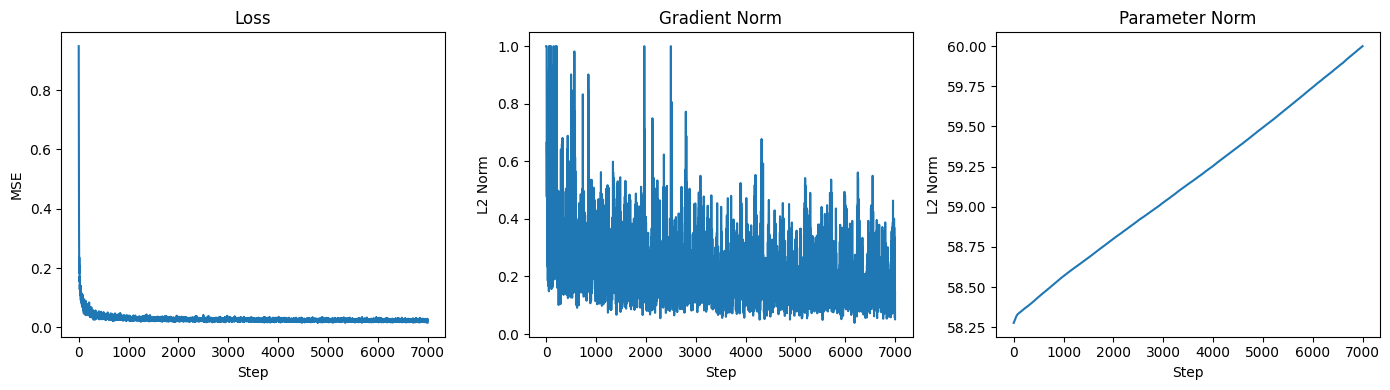

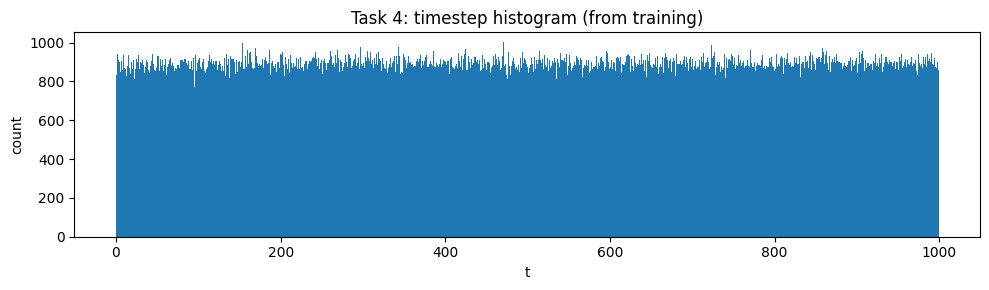

In [10]:
if len(train_stats["losses"]) > 0:
    plot_training_diagnostics(
        losses=train_stats["losses"],
        grad_norms=train_stats["grad_norms"],
        param_norms=train_stats["param_norms"],
    )
    plot_timestep_histogram(train_stats["timestep_counts"], title="Task 4: timestep histogram (from training)")
else:
    print("No fresh Task-4 stats in memory (training skipped).")

In [11]:
RUN_OVERFIT_TRAIN = True  # set False to reuse overfit checkpoint

if RUN_OVERFIT_TRAIN or (not OVERFIT_CKPT.exists()):
    overfit_model, overfit_schedule, overfit_losses, overfit_stats = train_ddpm_overfit_subset(
        subset_size=256,
        steps=1000,
        batch_size=64,
        sample_every=250,
        checkpoint_path=OVERFIT_CKPT,
    )
    print("Overfit last loss:", overfit_losses[-1])
    print("Saved overfit checkpoint:", overfit_stats["checkpoint_path"])
    print("Overfit periodic sample grids:")
    for p in overfit_stats["sample_paths"]:
        print(" -", p)
else:
    overfit_model, overfit_schedule = load_ddpm_checkpoint(OVERFIT_CKPT)
    print("Loaded overfit checkpoint:", OVERFIT_CKPT)

Task 4 Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Overfit last loss: 0.023988211527466774
Saved overfit checkpoint: outputs\checkpoints\tiny_unet_mnist_overfit256.pt
Overfit periodic sample grids:
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\overfit256_step_000250.png
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\overfit256_step_000500.png
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\overfit256_step_000750.png
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\overfit256_step_001000.png


In [12]:
posterior_check = one_step_posterior_sanity_check(
    schedule=schedule,
    batch_size=64,
    timestep=200,
    trials=30,
    train=False,
)
posterior_check

{'timestep': 200.0,
 'trials': 30.0,
 'mse_xt_to_x0': 0.37723347544670105,
 'mse_xprev_to_x0': 0.3739045262336731,
 'condition_holds': True}

In [13]:
noise_check = noise_prediction_sanity_check(
    model=model,
    schedule=schedule,
    batch_size=256,
    timestep=200,
    train=False,
)
noise_check

{'timestep': 200.0,
 'noise_corr': 0.9808998107910156,
 'noise_mse': 0.037746746093034744}

{'max_abs_freq_error': 0.00022499996703118086, 'relative_std_error': 0.07169651240110397}


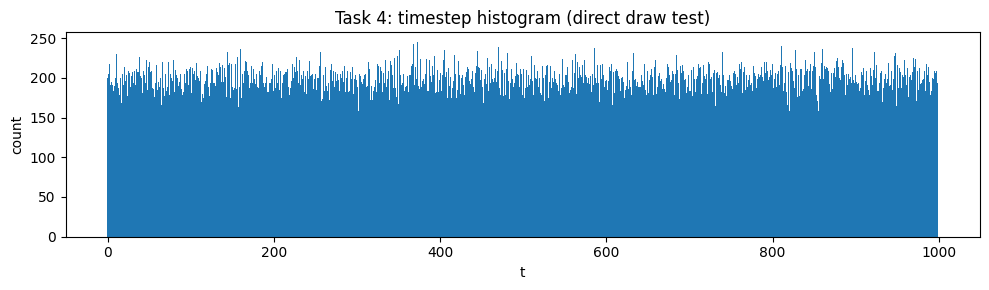

In [14]:
uniformity_check = timestep_uniformity_sanity_check(
    schedule=schedule,
    num_draws=200000,
    batch_size=1024,
)
print({k: v for k, v in uniformity_check.items() if k not in ["counts", "freq", "expected_freq"]})
plot_timestep_histogram(uniformity_check["counts"], title="Task 4: timestep histogram (direct draw test)")

In [15]:
model, schedule = load_ddpm_checkpoint(TASK4_CKPT)
samples = sample_and_save_grid(model, schedule)
save_denoising_trajectory(model, schedule)
save_checkpoint(model, TASK5_CKPT)
print("Sample tensor shape:", tuple(samples.shape))
print("Saved: outputs/samples/final_samples.png")
print("Saved: outputs/samples/trajectory.png")
print("Saved Task-5 checkpoint:", TASK5_CKPT)

Sample tensor shape: (64, 1, 28, 28)
Saved: outputs/samples/final_samples.png
Saved: outputs/samples/trajectory.png
Saved Task-5 checkpoint: outputs\checkpoints\tiny_unet_mnist_task5.pt
